# Modèles linéaires - KMAXPP05

## Configuration du notebook

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Régression linéaire

In [2]:
# X contient le poids [kg] de joueurs de rubgy et Y contient la taille [cm]
X = np.array([190., 172., 186., 180.]).reshape(-1, 1)
Y = np.array([112., 85., 135., 92.]).reshape(-1, 1)

In [3]:
X

array([[190.],
       [172.],
       [186.],
       [180.]])

In [4]:
Y

array([[112.],
       [ 85.],
       [135.],
       [ 92.]])

In [5]:
# Une fonction pour le passage à l'espace augmenté
def phi(X):
    ones = np.ones((X.shape[0], 1))
    return np.hstack((ones, X))

In [6]:
X_tilde = phi(X)
X_tilde

array([[  1., 190.],
       [  1., 172.],
       [  1., 186.],
       [  1., 180.]])

In [7]:
X_tilde.T @ X_tilde

array([[4.0000e+00, 7.2800e+02],
       [7.2800e+02, 1.3268e+05]])

In [8]:
# Dans la pratique on ne calcule pas l'inverse de la matrice. Cette approche est pour 'coller' à la solution présentée en cours.
Inv = np.linalg.inv(X_tilde.T @ X_tilde)

In [9]:
beta = Inv @ X_tilde.T @ Y

In [10]:
Y_hat = X_tilde @ beta
Y_hat

array([[123.47826087],
       [ 84.15217391],
       [114.73913043],
       [101.63043478]])

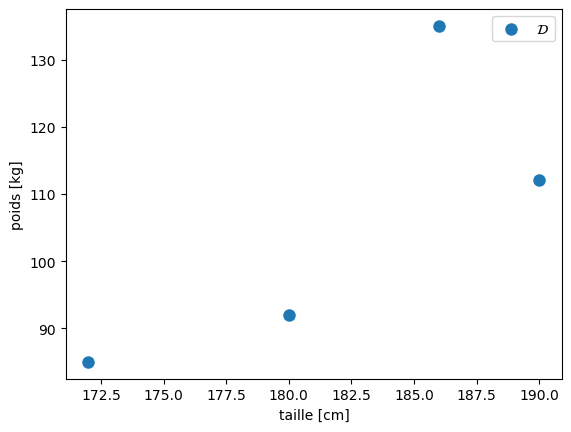

In [11]:
plt.scatter(X, Y, edgecolor="w", label=r"$\mathcal{D}$", s=100);
plt.xlabel("taille [cm]")
plt.ylabel("poids [kg]")
plt.legend();

In [12]:
# Inférence avec le modèle sur de nouvelles tailles
Xi = np.linspace(170., 200., 100).reshape(-1, 1)
Xi_tilde = phi(Xi)
Y_hat_i = Xi_tilde @ beta

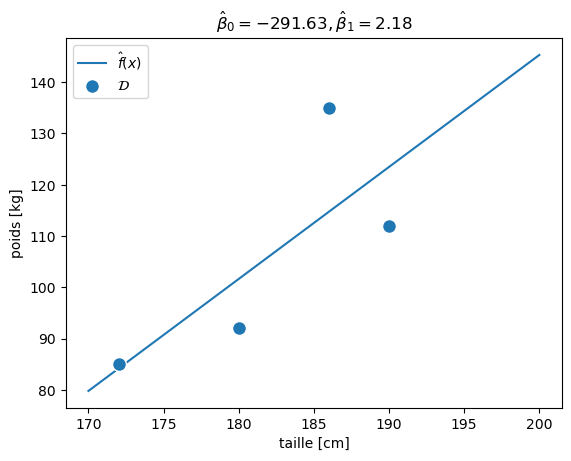

In [13]:
plt.plot(Xi, Y_hat_i, label=r"$\hat{f}(x)$")
plt.scatter(X, Y, edgecolor="w", label=r"$\mathcal{D}$", s=100, zorder=10)
plt.xlabel("taille [cm]")
plt.ylabel("poids [kg]")
plt.title(fr"$\hat{{\beta}}_0 = {beta[0, 0]:.2f}, \hat{{\beta}}_1 = {beta[1, 0]:.2f}$")
plt.legend();

In [14]:
# Vecteur beta arbitraire pour illustrer la méthode des moindres carrés
beta = np.array([[-250.0], [1.6]])
Y_hat_i = Xi_tilde @ beta
Y_hat = X_tilde @ beta

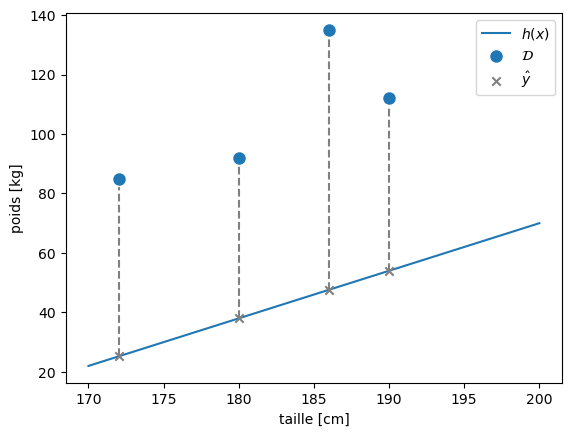

In [15]:
plt.plot(Xi, Y_hat_i, label=r"$h(x)$")
plt.scatter(X, Y, edgecolor="w", label=r"$\mathcal{D}$", zorder=10, s=100)
plt.scatter(X, Y_hat, marker="x", color="gray", zorder=10, label=r"$\hat{y}$")
plt.xlabel("taille [cm]")
plt.ylabel("poids [kg]")
for (x, y, y_hat) in zip(X, Y, Y_hat):
    plt.vlines(x, min(y, y_hat), max(y, y_hat), ls="--", color="gray")
plt.legend();

In [16]:
beta = Inv @ X_tilde.T @ Y
Y_hat_i = Xi_tilde @ beta
Y_hat = X_tilde @ beta

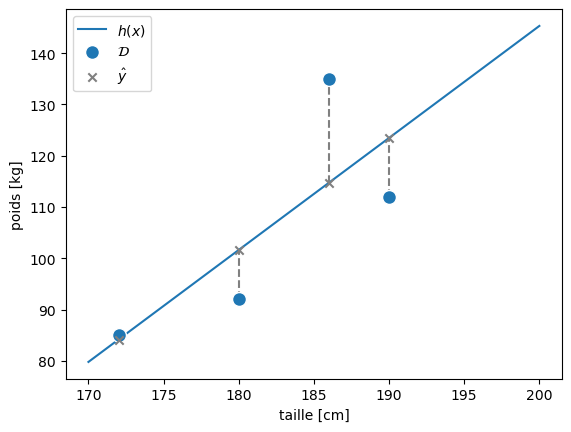

In [17]:
plt.plot(Xi, Y_hat_i, label=r"$h(x)$")
plt.scatter(X, Y, edgecolor="w", label=r"$\mathcal{D}$", zorder=10, s=100)
plt.scatter(X, Y_hat, marker="x", color="gray", zorder=10, label=r"$\hat{y}$")
plt.xlabel("taille [cm]")
plt.ylabel("poids [kg]")
for (x, y, y_hat) in zip(X, Y, Y_hat):
    plt.vlines(x, min(y, y_hat), max(y, y_hat), ls="--", color="gray")
plt.legend();

In [18]:
X1_tilde = phi(X)
X1_tilde

array([[  1., 190.],
       [  1., 172.],
       [  1., 186.],
       [  1., 180.]])

In [19]:
X3_tilde = phi(np.hstack((X, X**2, X**3)))
X3_tilde

array([[1.000000e+00, 1.900000e+02, 3.610000e+04, 6.859000e+06],
       [1.000000e+00, 1.720000e+02, 2.958400e+04, 5.088448e+06],
       [1.000000e+00, 1.860000e+02, 3.459600e+04, 6.434856e+06],
       [1.000000e+00, 1.800000e+02, 3.240000e+04, 5.832000e+06]])

In [20]:
beta1 = np.linalg.inv(X1_tilde.T @ X1_tilde) @ X1_tilde.T @ Y
beta1

array([[-291.63043478],
       [   2.18478261]])

In [21]:
beta3 = np.linalg.inv(X3_tilde.T @ X3_tilde) @ X3_tilde.T @ Y
beta3

array([[ 5.70850930e+05],
       [-9.48480366e+03],
       [ 5.24880300e+01],
       [-9.67260704e-02]])

In [22]:
Xi = np.linspace(170., 200., 100).reshape(-1, 1)
X1i_tilde = phi(Xi)
X3i_tilde = phi(np.hstack((Xi, Xi**2, Xi**3)))
Y_hat_i1 = X1i_tilde @ beta1
Y_hat_i3 = X3i_tilde @ beta3

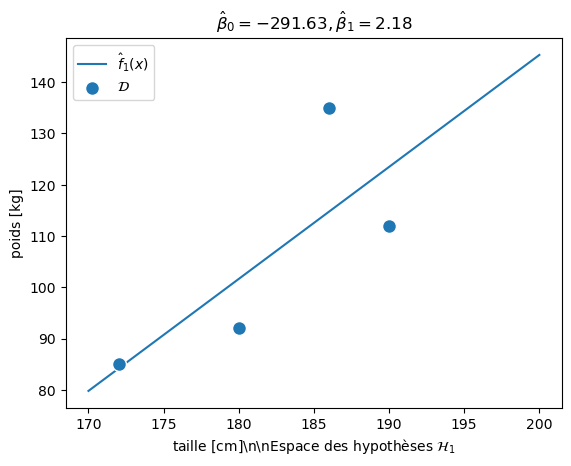

In [23]:
plt.plot(Xi, Y_hat_i1, label=r"$\hat{f}_1(x)$")
plt.scatter(X, Y, edgecolor="w", label=r"$\mathcal{D}$", zorder=10, s=100)
plt.xlabel(r"taille [cm]\n\nEspace des hypothèses $\mathcal{H}_1$")
plt.ylabel("poids [kg]")
plt.title(fr"$\hat{{\beta}}_0 = {beta1[0, 0]:.2f}, \hat{{\beta}}_1 = {beta1[1, 0]:.2f}$")
plt.legend();

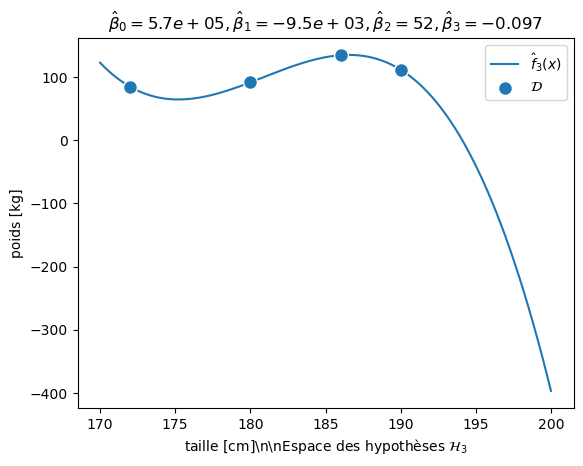

In [24]:
plt.plot(Xi, Y_hat_i3, label=r"$\hat{f}_3(x)$")
plt.scatter(X, Y, edgecolor="w", label=r"$\mathcal{D}$", zorder=10, s=100)
plt.xlabel(r"taille [cm]\n\nEspace des hypothèses $\mathcal{H}_3$")
plt.ylabel("poids [kg]")
plt.title(fr"$\hat{{\beta}}_0 = {beta3[0, 0]:.2g}, \hat{{\beta}}_1 = {beta3[1, 0]:.2g}, \hat{{\beta}}_2 = {beta3[2, 0]:.2g}, \hat{{\beta}}_3 = {beta3[3, 0]:.2g}$")
plt.legend();

Plus de données de joueurs depuis le site: https://www.allrugby.com/clubs/france/effectif

In [25]:
X = np.array(
    [175., 180., 185., 186., 185., 177., 182., 181., 184., 203., 200., 205., 197., 203., 203., 195., 199., 
     191., 190., 192., 169., 177., 175., 186., 185., 190., 184., 194., 188., 188., 185., 178.]
).reshape(-1, 1)
Y = np.array(
    [115., 119., 112., 133., 124., 125., 107., 110., 109., 142., 105., 133., 122., 138., 116., 108., 114., 
     114., 90., 107., 82., 83., 75., 94., 89., 100., 97., 94, 102., 97., 84., 87.]
).reshape(-1, 1)

In [26]:
X1_tilde = phi(X)
X3_tilde = phi(np.hstack((X, X**2, X**3)))
beta1 = np.linalg.inv(X1_tilde.T @ X1_tilde) @ X1_tilde.T @ Y
beta3 = np.linalg.inv(X3_tilde.T @ X3_tilde) @ X3_tilde.T @ Y

In [27]:
Xi = np.linspace(170., 210., 100).reshape(-1, 1)
X1i_tilde = phi(Xi)
X3i_tilde = phi(np.hstack((Xi, Xi**2, Xi**3)))
Y_hat_i1 = X1i_tilde @ beta1
Y_hat_i3 = X3i_tilde @ beta3

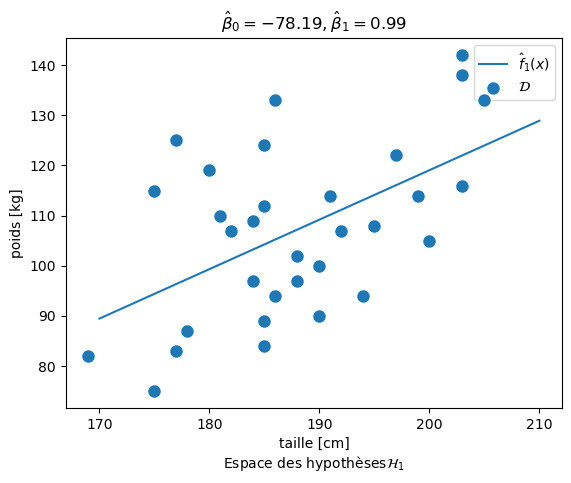

In [28]:
plt.plot(Xi, Y_hat_i1, label=r"$\hat{f}_1(x)$")
plt.scatter(X, Y, edgecolor="w", label=r"$\mathcal{D}$", zorder=10, s=100)
plt.xlabel("taille [cm]\nEspace des hypothèses" + r"$\mathcal{H}_1$")
plt.ylabel("poids [kg]")
plt.title(fr"$\hat{{\beta}}_0 = {beta1[0, 0]:.2f}, \hat{{\beta}}_1 = {beta1[1, 0]:.2f}$")
plt.legend();

In [29]:
Y_hat_1 = X1_tilde @ beta1
r = Y - Y_hat_1
R2 = 1 - np.sum(r**2) / np.sum((Y - Y.mean())**2)
R2

np.float64(0.2852304759600688)

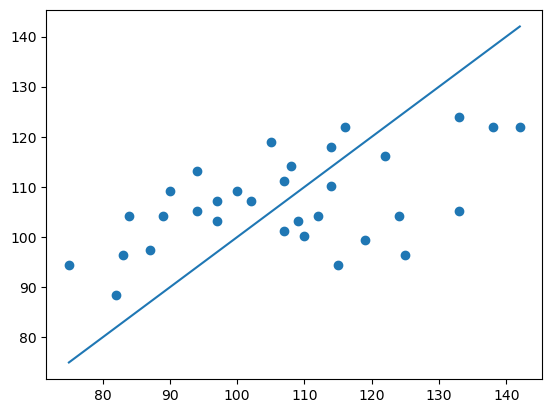

In [30]:
isort = np.argsort(Y, axis=0).squeeze()
plt.scatter(Y, Y_hat_1);
plt.plot(Y[isort], Y[isort]);

In [31]:
# Le coefficient de détermination R2 est le carré du coefficient de corrélation de Pearson pour la régression lineéaire
np.corrcoef(Y, Y_hat_1, rowvar=False)[0,1]**2

np.float64(0.2852304759600688)

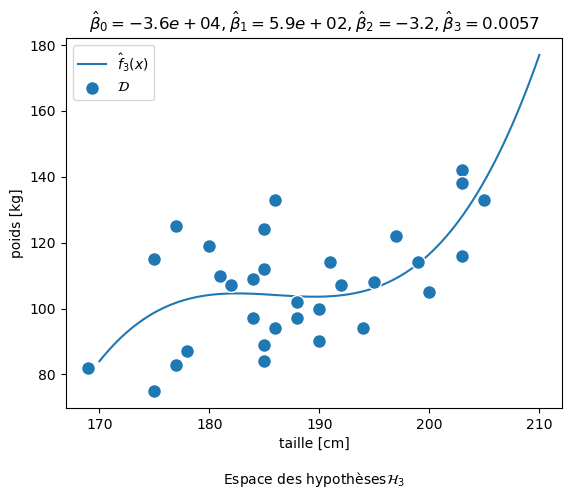

In [32]:
plt.plot(Xi, Y_hat_i3, label=r"$\hat{f}_3(x)$")
plt.scatter(X, Y, edgecolor="w", label=r"$\mathcal{D}$", zorder=10, s=100)
plt.xlabel("taille [cm]\n\nEspace des hypothèses" + r"$\mathcal{H}_3$")
plt.ylabel("poids [kg]")
plt.title(fr"$\hat{{\beta}}_0 = {beta3[0, 0]:.2g}, \hat{{\beta}}_1 = {beta3[1, 0]:.2g}, \hat{{\beta}}_2 = {beta3[2, 0]:.2g}, \hat{{\beta}}_3 = {beta3[3, 0]:.2g}$")
plt.legend();

## Régression logistique

In [33]:
# Données des joueurs de rugby
X = np.array([[112.], [85.], [135.,], [92.]])  # poids
Y = np.array([[1], [0], [1], [0]])  # 1 avant, 0 trois-quart

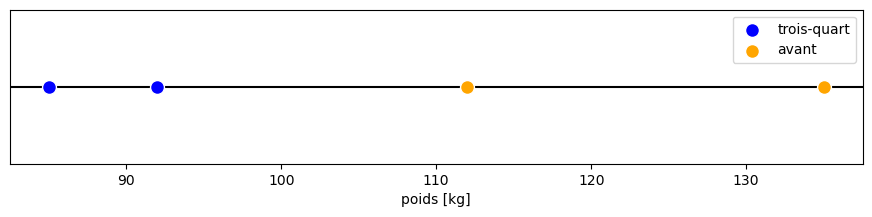

In [34]:
fig = plt.figure(figsize=(11, 2))
ax = fig.add_subplot(111)
mask = Y==0
ax.scatter(X[mask.ravel()], np.zeros(mask.sum()), c="blue", label="trois-quart", s=100, edgecolor="w")
ax.scatter(X[~mask.ravel()], np.zeros((~mask).sum()), c="orange", label="avant", s=100, edgecolor="w")
ax.axhline(0., c="k", zorder=0)
plt.xlabel("poids [kg]");
ax.legend();
ax.get_yaxis().set_visible(False);

In [35]:
def sigma(t):
    return 1 / (1 + np.exp(-t))

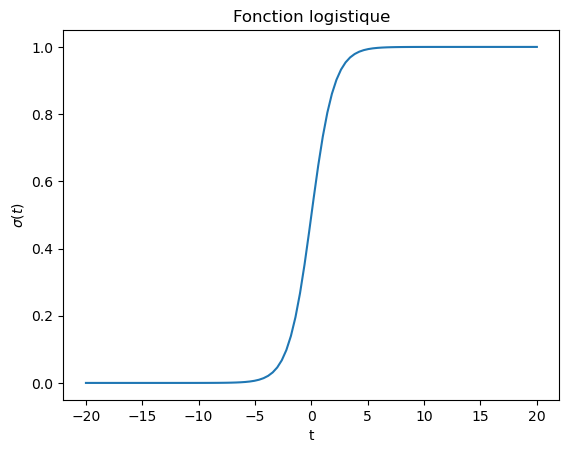

In [36]:
t = np.linspace(-20, 20., 100)
plt.plot(t, sigma(t))
plt.title("Fonction logistique");
plt.xlabel("t");
plt.ylabel(r"$\sigma(t)$");

In [37]:
def entropie_croisee_moyenne(X, Y):
    n = X.shape[0]
    X_tilde = phi(X)
    def inner(beta):
        beta = beta.reshape(2, 1)
        p = sigma(X_tilde @ beta)
        p = np.clip(p, 1e-15, 1 - 1e-15)  # pour éviter log(0)
        return -1 / n * np.sum(Y * np.log(p) + (1 - Y) * np.log(1 - p))
    return inner

In [38]:
def gradient(X, Y):
    n = X.shape[0]
    X_tilde = phi(X)
    def inner(beta):
        return -1/n * X_tilde.T @ (Y - sigma(X_tilde @ beta))
    return inner

In [39]:
f = entropie_croisee_moyenne((X - X.mean(axis=0)) / X.std(axis=0), Y)

In [40]:
g = gradient((X - X.mean(axis=0)) / X.std(axis=0), Y)

In [41]:
beta = np.array([1., 20.]).reshape(-1, 1)

In [42]:
alpha = 0.1
tol = 1e-10
itermax = 100000
k = 0

In [43]:
while True:
    k += 1
    delta = -alpha * g(beta)
    beta += delta
    if np.sum(delta**2) <= tol:
        print(f"Convergence atteinte après {k} itérations. Beta = {beta.ravel()}")
        break
    if k >= itermax:
        print(f"Pas de convergence après {k} itérations.")
        break

Convergence atteinte après 47861 itérations. Beta = [ 1.63524067 20.1984094 ]


In [44]:
f(beta), g(beta)

(np.float64(9.66433337941394e-05),
 array([[-9.53745858e-05],
        [-3.00566114e-05]]))

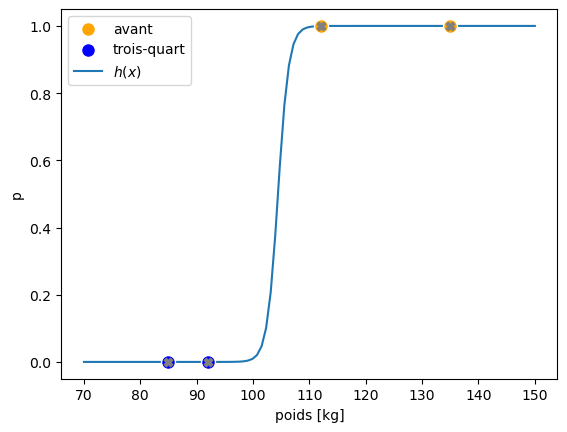

In [45]:
Xi = np.linspace(70., 150., 100).reshape(-1, 1)
X_tilde = phi((X - X.mean(axis=0))/X.std(axis=0))
Xi_tilde = phi((Xi - X.mean(axis=0))/X.std(axis=0))
pi = sigma(Xi_tilde @ beta)
p = sigma(X_tilde @ beta) 
plt.scatter(X[[0, 2]], Y[[0, 2]], s=100, edgecolor="w", color="orange", zorder=10, label="avant")
plt.scatter(X[[1, 3]], Y[[1, 3]], s=100, edgecolor="w", color="blue", zorder=10, label="trois-quart")
plt.plot(Xi, pi, label=r"$h(x)$");
plt.scatter(X, p, marker="X", color="gray", zorder=10)
for x, y, p_ in zip(X, Y, p):
     plt.vlines(x, min(y, p_), max(y, p_), color="gray", ls="--")
plt.xlabel("poids [kg]");
plt.ylabel("p");
plt.legend();

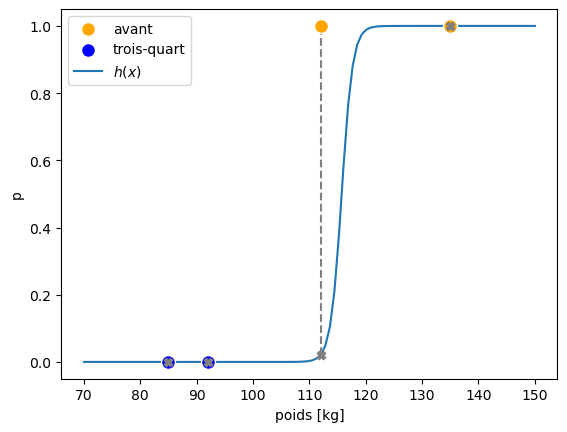

In [46]:
beta = np.array([[-10.], [20.]])
pi = sigma(Xi_tilde @ beta)
plt.scatter(X[[0, 2]], Y[[0, 2]], s=100, edgecolor="w", color="orange", zorder=10, label="avant")
plt.scatter(X[[1, 3]], Y[[1, 3]], s=100, edgecolor="w", color="blue", zorder=10, label="trois-quart")
plt.plot(Xi, pi, label=r"$h(x)$");
plt.scatter(X, sigma(X_tilde @ beta), marker="X", color="gray", zorder=10)
for x, y, p_ in zip(X, Y, sigma(X_tilde @ beta)):
    plt.vlines(x, min(y, p_), max(y, p_), color="gray", ls="--")
plt.xlabel("poids [kg]");
plt.ylabel("p");
plt.legend();

## Courbe ROC

In [47]:
p = np.array([0.98, 0.2, 0.05, 0.60, 0.79, 0.83, 0.47])
y = np.array([True, False, False, False, True, False, True])
theta = np.linspace(0., 1., 101)

In [48]:
def calcul_tfp_tvp(p, y, theta):
    tfp = []
    tvp = []
    for t in theta:
        vp = y[p >= t].sum()
        fp = (~y)[p >= t].sum()
        vn = (~y)[p < t].sum()
        fn = y[p < t].sum()
        tfp.append(fp / (fp + vn))
        tvp.append(vp / (vp + fn))
    return np.array(tfp), np.array(tvp)

In [49]:
tfp, tvp = calcul_tfp_tvp(p, y, theta)

In [50]:
tfp_theta, tvp_theta = calcul_tfp_tvp(p, y, np.array([0.]))

In [51]:
p>=0.

array([ True,  True,  True,  True,  True,  True,  True])

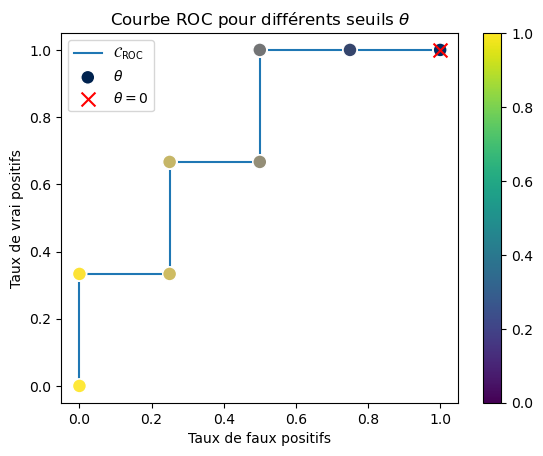

In [52]:
plt.plot(tfp, tvp, label=r"$\mathcal{C}_{\text{ROC}}$");
scatter = plt.scatter(tfp, tvp, c=theta, cmap="cividis", label=r"$\theta$", zorder=10, edgecolor="w", s=100)
scatter = plt.scatter(tfp_theta, tvp_theta, c="r", label=r"$\theta = 0$", zorder=20, s=100, marker="x")
plt.colorbar(scatter)
plt.legend()
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrai positifs")
plt.title(r"Courbe ROC pour différents seuils $\theta$");

In [53]:
tfp_theta, tvp_theta = calcul_tfp_tvp(p, y, np.array([1.]))

In [54]:
p>=1.

array([False, False, False, False, False, False, False])

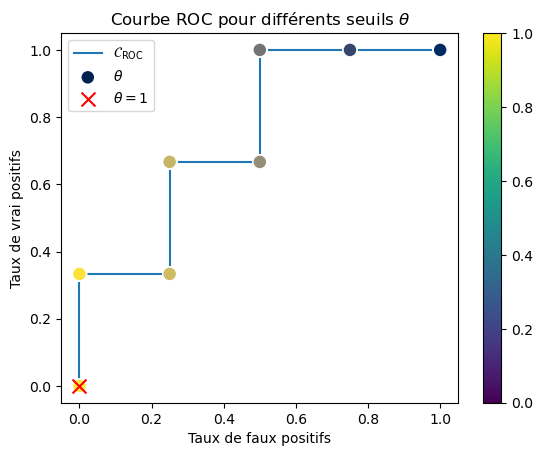

In [55]:
plt.plot(tfp, tvp, label=r"$\mathcal{C}_{\text{ROC}}$");
scatter = plt.scatter(tfp, tvp, c=theta, cmap="cividis", label=r"$\theta$", zorder=10, edgecolor="w", s=100)
scatter = plt.scatter(tfp_theta, tvp_theta, c="r", label=r"$\theta = 1$", zorder=20, s=100, marker="x")
plt.colorbar(scatter)
plt.legend()
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrai positifs")
plt.title(r"Courbe ROC pour différents seuils $\theta$");

In [56]:
tfp_theta, tvp_theta = calcul_tfp_tvp(p, y, np.array([0.5]))

In [57]:
p >= 0.5

array([ True, False, False,  True,  True,  True, False])

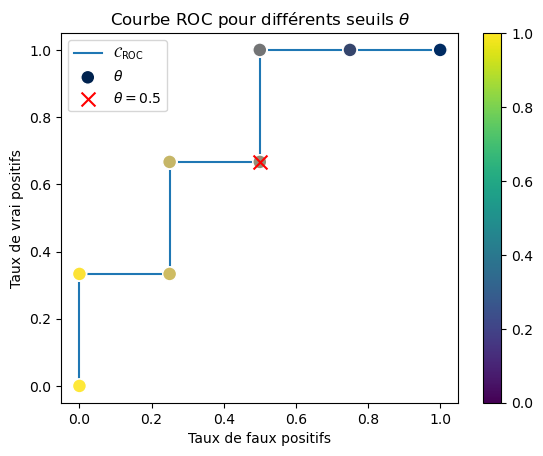

In [58]:
plt.plot(tfp, tvp, label=r"$\mathcal{C}_{\text{ROC}}$");
scatter = plt.scatter(tfp, tvp, c=theta, cmap="cividis", label=r"$\theta$", zorder=10, edgecolor="w", s=100)
scatter = plt.scatter(tfp_theta, tvp_theta, c="r", label=r"$\theta = 0.5$", zorder=20, s=100, marker="x")
plt.colorbar(scatter)
plt.legend()
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrai positifs")
plt.title(r"Courbe ROC pour différents seuils $\theta$");